# Sentiment classification with BERT - Exploiting multi-layer feature extraction

`imdb_reviews` dataset is a large movie review dataset. This dataset is for binary sentiment classification containing a set of 25,000 highly polar movie reviews for training, and 25,000 for testing. All the reviews have either a *positive* or *negative* sentiment.
Reference: http://ai.stanford.edu/~amaas/data/sentiment/

Each data sample contains:
* label (tf.int64)
* text (tf.string)

In this assignment, you will exploit multi-layer feature extraction of a BERT model which comprises of several Transformer-encoder blocks. The model you will be using is as follows:
- Name: small_bert/bert_en_uncased_L-4_H-128_A-2
- Number of layers, i.e., Transformer-encoder blocks: 4.
- Number of hidden states: 128.
- Number of attention heads: 2.
- Model on TFHub: https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1
- Preprocessing module on TFHub: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3

Since the BERT model has 4 encoder blocks and each outputs an embedding feature vector, your task is to find a way to make use of the multi-layer features to boost the classification accuracy. There are some questions you need to figure out:
- How to get embedding feature vector of each encoder block.
- How to combine the embedding feature vectors of the encoder blocks.
- How to make use of the combined embedding feature vector to boost the model performance.

1.  **(5 points) Coding Tasks:** The following questions involve writing code to complete specific tasks.  
    1.1 *(1 point)* Tokenize and preprocess the IMDB dataset using the BERT preprocessing module from TFHub. Show the code that prepares the text data for the BERT model.  
    1.2 *(1 point)* Extract the embedding feature vectors from each of the four encoder blocks in the BERT model. Provide the code to retrieve these embeddings.  
    1.3 *(1 point)* Combine the embedding feature vectors from the four encoder blocks into a single vector. Show the code used for concatenating or pooling the embeddings.  
    1.4 *(1 point)* Construct the classification model using the combined embedding feature vector. Provide the code for building the model.   
    1.5 *(1 point)* Evaluate the performance of your model on the test set. Provide the code to compute accuracy or other relevant metrics.  

2.  **(5 points) Open discussion questions:** These discussion questions ask you to analyze and argue your points.  Feel free to include relevant code examples to strengthen your arguments.  
    2.1 *(1 point)* What effect do you think the preprocessing step (tokenization, padding, etc.) has on the quality of the embeddings? How important is this step in fine-tuning BERT for sentiment classification?  
    2.2 *(1 point)* How do the multi-layer features from BERT potentially improve the sentiment classification task? What could be the impact of using features from higher or lower layers of the model?  
    2.3 *(1 point)* What challenges did you face when training the BERT model for this sentiment classification task? Did you encounter any issues related to overfitting, training time, or convergence?  
    2.4 *(1 point)* Do you think BERT is well-suited for sentiment analysis tasks? Why or why not? What other models or approaches could also be effective for sentiment classification?  
    2.5 *(1 point)* If you were to improve your model, what changes would you make? Would you consider fine-tuning the BERT model or experimenting with different methods for combining features?  

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment-BERT-notebook.ipynb: Jupyter notebook containing source code.

### Evaluation {-}
Assignment evaluation will be conducted on how you accomplish the assignment requirements. In addition, your code should conform to a Python coding convention such as PEP-8.

### Deadline {-}
Please visit Canvas for details.

# Install and load libraries

In [1]:
# Download tensorflow datasets
!pip install tensorflow-datasets==4.9.2

# A dependency of the preprocessing for BERT inputs
# !pip install tensorflow-text==2.15.0 (I installed manually on macos, because tensorflow-macos just support from versions: 2.17.0rc0, 2.17.0, 2.18.0rc0, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0)
# https://github.com/sun1638650145/Libraries-and-Extensions-for-TensorFlow-for-Apple-Silicon/releases (I downloaded the tensorflow-text-2.15.0-macos11_x86_64.whl and installed it manually)
!pip install tensorflow-hub==0.15.0

In [2]:
!pip install keras==2.15.0
!pip install ml-dtypes==0.2.0
!pip install tensorboard==2.15.1

In [3]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

import tensorflow_datasets as tfds
import tensorflow as tf
from tensorflow import keras
import tensorflow_hub as hub
import tensorflow_text as text

/Users/nhuquynhtran/Downloads/Tensorflow Env/tf215-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load the dataset


In [4]:
# Load and split the data into training, validation and test data
train_dataset, val_dataset, test_dataset = tfds.load(name="imdb_reviews", split=('train[:80%]', 'train[80%:]', 'test'), as_supervised=True)

print("Training set: ", len(train_dataset), "samples")
print("Validation set: ", len(val_dataset), "samples")
print("Test set: ", len(test_dataset), "samples")

Training set:  20000 samples
Validation set:  5000 samples
Test set:  25000 samples


In [5]:
### Convert Tensorflow Dataset to numpy arrays of feature vector X and label y

# Convert training set
train_ds_numpy = tfds.as_numpy(train_dataset) # Convert TF Dataset to an iterable of numpy array
train_numpy = np.vstack(list(train_ds_numpy)) # Stack to full numpy array
X_train = np.array(list(map(lambda x: x[0], train_numpy))) # Extract review (index 0) from numpy vector
y_train = np.array(list(map(lambda x: x[1], train_numpy))).astype(np.int16) # Extract label (index 1) from numpy vector and convert grom string to number
print("X_train shape: " + str(X_train.shape))
print("y_train shape: " + str(y_train.shape))

# Convert validation set
val_ds_numpy = tfds.as_numpy(val_dataset) # Convert TF Dataset to an iterable of numpy array
val_numpy = np.vstack(list(val_ds_numpy)) # Stack to full numpy array
X_val = np.array(list(map(lambda x: x[0], val_numpy))) # Extract review (index 0) from numpy vector
y_val = np.array(list(map(lambda x: x[1], val_numpy))).astype(np.int16) # Extract label (index 1) from numpy vector
print("X_val shape: " + str(X_val.shape))
print("y_val shape: " + str(y_val.shape))

# Convert test set
test_ds_numpy = tfds.as_numpy(test_dataset) # Convert TF Dataset to an iterable of numpy array
test_numpy = np.vstack(list(test_ds_numpy)) # Stack to full numpy array
X_test = np.array(list(map(lambda x: x[0], test_numpy))) # Extract review (index 0) from numpy vector
y_test = np.array(list(map(lambda x: x[1], test_numpy))).astype(np.int16) # Extract label (index 1) from numpy vector
print("X_test shape: " + str(X_test.shape))
print("y_test shape: " + str(y_test.shape))

X_train shape: (20000,)
y_train shape: (20000,)
X_val shape: (5000,)
y_val shape: (5000,)
X_test shape: (25000,)
y_test shape: (25000,)


In [6]:
### Below are two examples of BERT models with corresponding preprocessings for use with them
# Full list of BERT models supported by Tensorflow can be found at https://tfhub.dev/google/collections/bert/1

# Mapping from name to URL of Bert models
map_name_to_model = {
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1',
}

# Mapping from name to URL of respective processings for the Bert models
map_name_to_preprocess = {
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

### Choose a model: Small BERT model for English language with L-4_H-128_A-2. This means the BERT model has:
# - 4 layers, i.e., 4 Transformer-encoder blocks.
# - Hidden states = 128.
# - Attention heads = 2.
# This Small BERT model is available at https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1
bert_name = 'small_bert/bert_en_uncased_L-4_H-128_A-2'

# Get URLs of model and processing from tfhub
tfhub_model = map_name_to_model[bert_name]
tfhub_preprocess = map_name_to_preprocess[bert_name]

print('BERT model selected           : ' + str(tfhub_model))
print('Preprocess model auto-selected: ' + str(tfhub_preprocess))

BERT model selected           : https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3


## 1. Coding tasks

In [ ]:
# Your code goes here
# 1.1: Tokenize and preprocess IMDB using BERT preprocessing module
# Preprocessing layer from TFHub
bert_preprocess = hub.KerasLayer(tfhub_preprocess)

In [ ]:
# Usage on raw text input
text_input = keras.layers.Input(shape=(), dtype=tf.string, name='text')
preprocessed_text = bert_preprocess(text_input)

In [ ]:
# Your code goes here
# 1.2: Extract embedding feature vectors from each of the 4 encoder blocks
bert_encoder = hub.KerasLayer(tfhub_model, trainable=True)

bert_outputs = bert_encoder(preprocessed_text)
encoder_outputs = bert_outputs['encoder_outputs']  # List of 4 Tensors (one per block)

In [10]:
cls_embeddings = [tf.squeeze(output[:, 0:1, :], axis=1) for output in encoder_outputs]

In [ ]:
# Your code goes here
# 1.3: Combine the embedding feature vectors from the four encoder blocks
combined_cls = tf.keras.layers.Concatenate()(cls_embeddings)


In [ ]:
# Your code goes here
# 1.4: Construct the classification model using the combined embedding
def build_cls_concat_model():
    text_input = keras.layers.Input(shape=(), dtype=tf.string, name='text')
    
    # BERT Preprocessing
    preprocessing_layer = hub.KerasLayer(tfhub_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    
    # BERT Encoder
    encoder = hub.KerasLayer(tfhub_model, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)
    
    # Extract CLS token from each encoder layer
    encoder_outputs = outputs['encoder_outputs']
    cls_embeddings = [tf.squeeze(out[:, 0:1, :], axis=1) for out in encoder_outputs]
    
    # Concatenate all 4 CLS token vectors
    combined_cls = tf.keras.layers.Concatenate()(cls_embeddings)
    
    # Classification head
    net = keras.layers.Dense(128, activation='relu')(combined_cls)
    net = keras.layers.BatchNormalization()(net)
    net = keras.layers.Dropout(0.5)(net)
    net = keras.layers.Dense(1, activation='sigmoid', name='classifier')(net)
    
    return keras.Model(inputs=text_input, outputs=net, name="BERT_cls_concat_model")


In [13]:
model = build_cls_concat_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "BERT_cls_concat_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                              

In [ ]:
# Your code goes here
# 1.5: Evaluate the performance of your model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    batch_size=64,
                    epochs=5)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


Epoch 1/5
313/313 [==============================] - 157s 503ms/step - loss: 0.7379 - accuracy: 0.6195 - val_loss: 0.5311 - val_accuracy: 0.7342
Epoch 2/5
313/313 [==============================] - 151s 483ms/step - loss: 0.6089 - accuracy: 0.7048 - val_loss: 0.4724 - val_accuracy: 0.7796
Epoch 3/5
313/313 [==============================] - 194s 620ms/step - loss: 0.5341 - accuracy: 0.7504 - val_loss: 0.4412 - val_accuracy: 0.7938
Epoch 4/5
313/313 [==============================] - 175s 559ms/step - loss: 0.4974 - accuracy: 0.7695 - val_loss: 0.4385 - val_accuracy: 0.7978
Epoch 5/5
782/782 [==============================] - 75s 96ms/step - loss: 0.4517 - accuracy: 0.7981
Test Loss: 0.4517033100128174
Test Accuracy: 0.7981200218200684


In [18]:
# Optional: Detailed metrics
from sklearn.metrics import classification_report

y_pred = (model.predict(X_test).flatten() > 0.5).astype(int)
print(classification_report(y_test, y_pred))

782/782 [==============================] - 68s 87ms/step
              precision    recall  f1-score   support

           0       0.84      0.73      0.78     12500
           1       0.76      0.87      0.81     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000



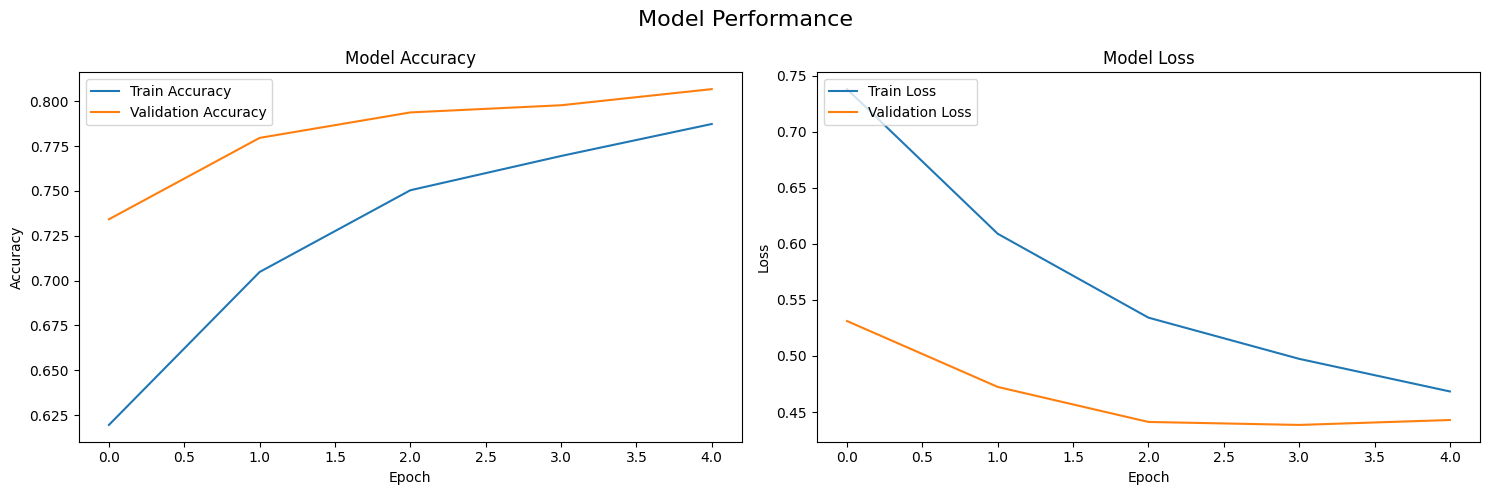

In [25]:
# Plot the model training performance over epochs with subplots
def plot_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Model Performance', fontsize=16)
    
    # Plot training & validation accuracy values
    axs[0].plot(history.history['accuracy'], label='Train Accuracy')
    axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(loc='upper left')
    
    # Plot training & validation loss values
    axs[1].plot(history.history['loss'], label='Train Loss')
    axs[1].plot(history.history['val_loss'], label='Validation Loss')
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(loc='upper left')

    plt.tight_layout()
    plt.show()
plot_history(history)

In [27]:
# Predict some movie reviews
def predict_review(review):
    review = np.array([review])
    prediction = model.predict(review)
    return "Positive" if prediction[0][0] > 0.5 else "Negative"
# Test the prediction function
print(predict_review("This movie was fantastic! I loved it."))
print(predict_review("This movie was terrible. I hated it."))
print(predict_review("The acting was great, but the plot was boring."))
print(predict_review("An absolute masterpiece! A must-watch for everyone."))

1/1 [==============================] - 0s 21ms/step
Positive
1/1 [==============================] - 0s 21ms/step
Negative
1/1 [==============================] - 0s 16ms/step
Negative
1/1 [==============================] - 0s 18ms/step
Positive


## 2. Open discussion questions

In [ ]:
# Your argument goes here
# 2.1
# What effect do you think the preprocessing step (tokenization, padding, etc.) has on the quality of the embeddings? How important is this step in fine-tuning BERT for sentiment classification?  
# The preprocessing step is crucial for the quality of the embeddings. It ensures that the input text is in a format that BERT can understand, including tokenization, padding, and truncation. Proper preprocessing helps in maintaining the context and semantics of the text, which directly impacts the performance of the model in sentiment classification tasks. In fine-tuning BERT, this step is essential as it allows the model to learn from well-structured input data, leading to better generalization and accuracy.

In [ ]:
# Your argument goes here
# 2.2
# How do the multi-layer features from BERT potentially improve the sentiment classification task? What could be the impact of using features from higher or lower layers of the model?  
# The multi-layer features from BERT capture different levels of abstraction in the text. Lower layers tend to capture more syntactic information, while higher layers capture more semantic and contextual information. Using features from higher layers can improve sentiment classification as they provide a richer representation of the text, capturing nuances and context that are important for understanding sentiment. However, using features from lower layers might be beneficial for tasks that require a focus on specific syntactic structures or patterns.

In [ ]:
# Your argument goes here
# 2.3
# What challenges did you face when training the BERT model for this sentiment classification task? Did you encounter any issues related to overfitting, training time, or convergence? 
# Some challenges faced when training the BERT model for sentiment classification include:
# - Overfitting: BERT models are large and can easily overfit to the training data, especially with a small dataset. Regularization techniques like dropout and early stopping were necessary to mitigate this.
# - Training time: BERT models are computationally intensive and require significant resources for training. This can lead to longer training times, especially on larger datasets.
# - Convergence: Ensuring that the model converges to a good solution can be challenging, as BERT models can sometimes get stuck in local minima. Careful tuning of hyperparameters like learning rate and batch size was necessary to achieve convergence.

# Before training, I need to set up on macos the proper environment for Tensorflow and Tensorflow Text, which requires some manual installation steps. The problem is that TF Hub is not compatible with Keras 3 and TensorFlow 2.16+. TensorFlow v2.16 points tf.keras to Keras 3, which unfortunately breaks a number of workflows with tensorflow_hub. But on mac, the default version of the most previous version of TensorFlow is 2.16.2 and Keras 3.x, and the most recent version of TensorFlow is 2.19.0 and Keras 3.9.1, which is not compatible with TensorFlow Text 2.15.0.
# So I need to downgrade Keras to 2.15.0 and TensorFlow to 2.15.1, which is compatible with TensorFlow Text 2.15.0. Then I also need to downgrade into Python10 instead of Python13. The TensorFlow Text 2.15.0 needs to be installed manually on macos, because tensorflow-macos just supports from versions: 2.17.0rc0, 2.17.0, 2.18.0rc0, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0.
# I also need to install the ml-dtypes 0.2.0, tensorboard 2.15.1, tensorflow-hub 0.15.0, tensorflow-datasets 4.9.2, which is compatible with TensorFlow 2.15.1 and Keras 2.15.0.

In [ ]:
# Your argument goes here
# 2.4
# Do you think BERT is well-suited for sentiment analysis tasks? Why or why not? What other models or approaches could also be effective for sentiment classification?  
# BERT is well-suited for sentiment analysis tasks due to its ability to capture contextual information and understand the nuances of language. Its transformer architecture allows it to model long-range dependencies in text, making it effective for understanding sentiment. Other models or approaches that could be effective for sentiment classification include:
# - Other transformer-based models like RoBERTa, DistilBERT, or XLNet, which may offer improvements in performance or efficiency.
# - Traditional machine learning models like SVM or logistic regression with TF-IDF features, which can be effective for simpler tasks.
# - Recurrent Neural Networks (RNNs) or Long Short-Term Memory (LSTM) networks, which can also capture sequential information in text.

In [ ]:
# Your argument goes here
# 2.5
# If you were to improve your model, what changes would you make? Would you consider fine-tuning the BERT model or experimenting with different methods for combining features? 
# To improve the model, I would consider:
# - Fine-tuning the BERT model with a lower learning rate to allow for more precise adjustments to the pre-trained weights.
# - Experimenting with different methods for combining features, such as attention mechanisms or weighted combinations of features from different layers.
# - Exploring other transformer architectures or pre-trained models that may offer better performance.
# - Implementing more advanced regularization techniques to prevent overfitting, such as data augmentation or adversarial training.
# - Conducting hyperparameter tuning to find the optimal settings for batch size, learning rate, and dropout rates.
# - Using ensemble methods to combine predictions from multiple models for improved accuracy.